# Dataset Inspection

This notebook visualises the generated training pairs (input/label) across different count levels (alpha values).

**Dataset structure:**
- 500 phantoms × 5 alpha levels = 2500 (input, label) pairs
- `label`: OSEM reconstruction from **clean** sinogram (noise-free target)
- `input`: OSEM reconstruction from **noisy** sinogram (network input)
- Alpha values: `[1.0, 0.5, 0.25, 0.125, 0.05]` — lower alpha = more noise

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('../src')
from spect.baseline.generate_ellipsoids import generate_phantom

DATASET_DIR = "../data/dataset"
ALPHA_VALUES = [1.0, 0.5, 0.25, 0.125, 0.05]
ALPHA_DIRS = {a: f"alpha_{str(a).replace('.', 'p')}" for a in ALPHA_VALUES}
N_PHANTOMS = 3  # change to 500 after full dataset generation
PHANTOM_IDX = 0

print("Alpha directories:")
for a, d in ALPHA_DIRS.items():
    path = os.path.join(DATASET_DIR, d)
    files = os.listdir(path) if os.path.exists(path) else []
    print(f"  alpha={a}: {len(files)} files found in {d}/")

Alpha directories:
  alpha=1.0: 6 files found in alpha_1p0/
  alpha=0.5: 6 files found in alpha_0p5/
  alpha=0.25: 6 files found in alpha_0p25/
  alpha=0.125: 6 files found in alpha_0p125/
  alpha=0.05: 6 files found in alpha_0p05/


## 1. Single Phantom — All Alpha Levels

Compare input reconstructions across all 5 alpha values for phantom 0000.
Label is the same for all alpha levels (reconstructed from clean sinogram).

In [12]:
# Load label (same for all alpha)
label_path = os.path.join(DATASET_DIR, ALPHA_DIRS[1.0], f"label_{PHANTOM_IDX:04d}.npy")
label = np.load(label_path)

# Find best slice (where max value is)
z_max = label.argmax() // (label.shape[1] * label.shape[2])
print(f"Phantom {PHANTOM_IDX:04d} — label shape: {label.shape}")
print(f"Label min: {label.min():.4f}, max: {label.max():.4f}")
print(f"Best slice: z={z_max}")

# Load all inputs
inputs = {}
for alpha in ALPHA_VALUES:
    path = os.path.join(DATASET_DIR, ALPHA_DIRS[alpha], f"input_{PHANTOM_IDX:04d}.npy")
    inputs[alpha] = np.load(path)
    print(f"alpha={alpha}: min={inputs[alpha].min():.4f}, max={inputs[alpha].max():.4f}")

Phantom 0000 — label shape: (128, 128, 128)
Label min: 0.0000, max: 12.6213
Best slice: z=82
alpha=1.0: min=0.0000, max=18.4393
alpha=0.5: min=0.0000, max=11.3955
alpha=0.25: min=0.0000, max=7.3056
alpha=0.125: min=0.0000, max=5.2230
alpha=0.05: min=0.0000, max=18.1124


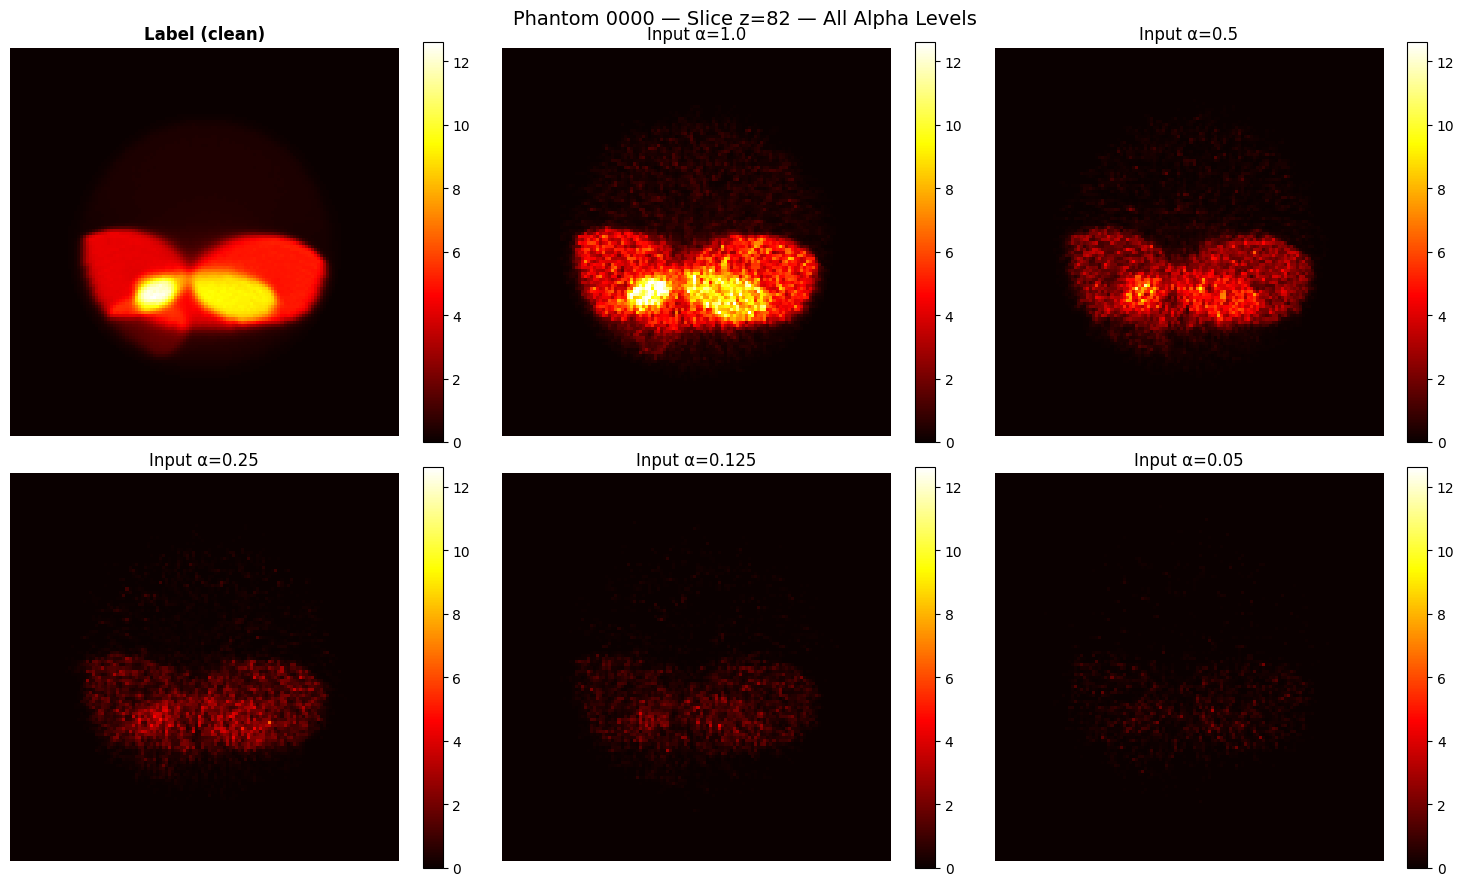

Saved to outputs/inspect_all_alphas.png


In [13]:
# Plot: label vs all inputs at best slice
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

vmax = label.max()

# Label
im = axes[0].imshow(label[z_max], cmap="hot", vmin=0, vmax=vmax)
axes[0].set_title("Label (clean)", fontsize=12, fontweight="bold")
axes[0].axis("off")
fig.colorbar(im, ax=axes[0])

# Inputs
for i, alpha in enumerate(ALPHA_VALUES):
    im = axes[i+1].imshow(inputs[alpha][z_max], cmap="hot", vmin=0, vmax=vmax)
    axes[i+1].set_title(f"Input α={alpha}", fontsize=12)
    axes[i+1].axis("off")
    fig.colorbar(im, ax=axes[i+1])

fig.suptitle(f"Phantom {PHANTOM_IDX:04d} — Slice z={z_max} — All Alpha Levels", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/inspect_all_alphas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/inspect_all_alphas.png")

## 2. Three Orthogonal Views — Label vs Noisiest Input (α=0.5)

Axial, coronal, and sagittal views to verify 3D structure.

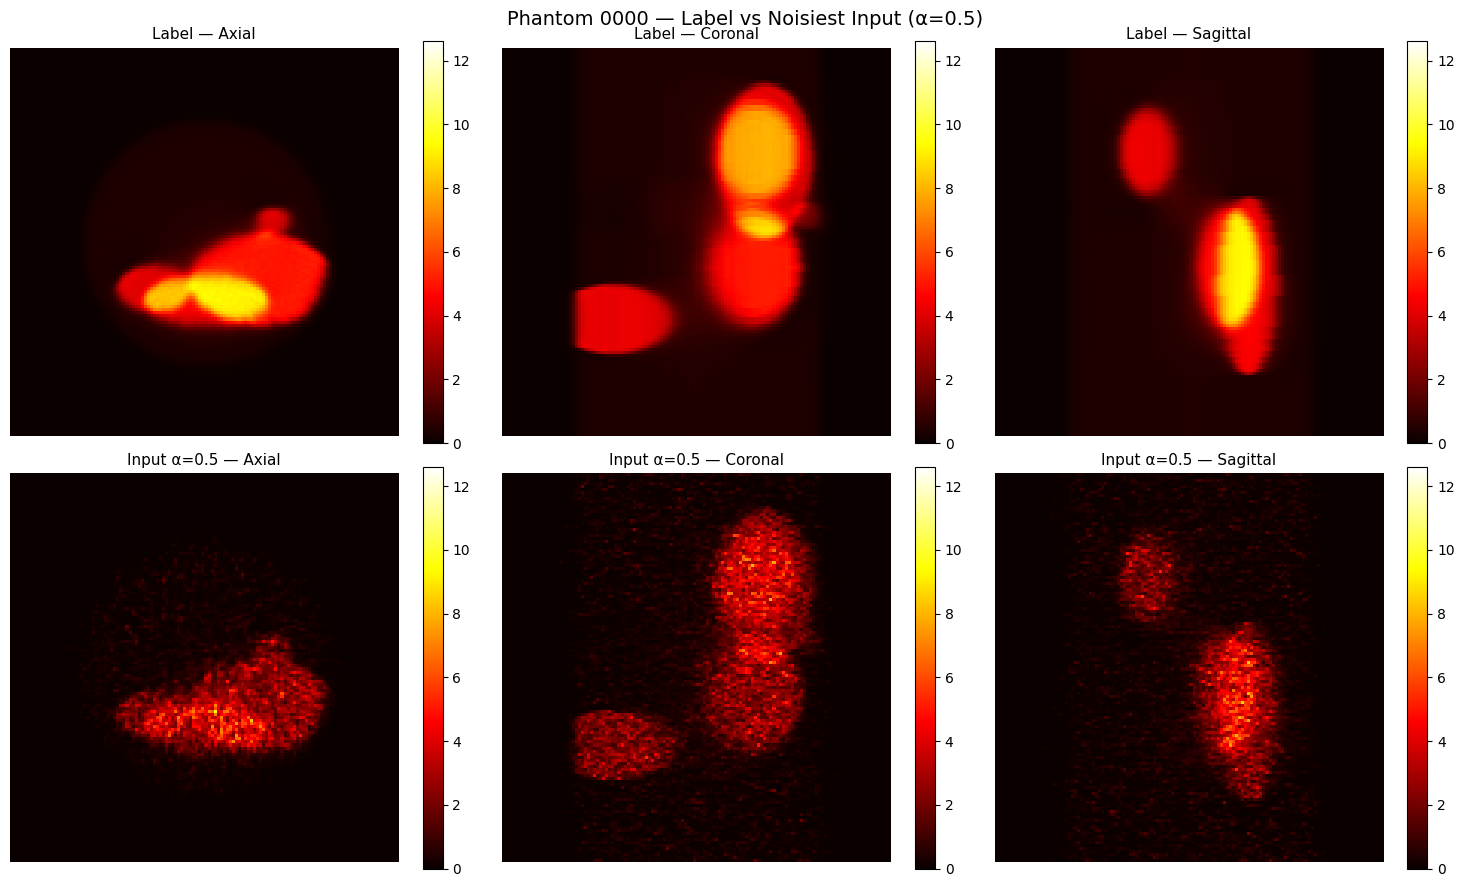

Saved to outputs/inspect_3views.png


In [14]:
inp_noisy = inputs[0.5]
D, H, W = label.shape

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
vmax = label.max()

views = [
    (label[D//2],       inp_noisy[D//2],       "Axial"),
    (label[:, H//2, :], inp_noisy[:, H//2, :], "Coronal"),
    (label[:, :, W//2], inp_noisy[:, :, W//2], "Sagittal"),
]

for col, (lbl_slice, inp_slice, title) in enumerate(views):
    im0 = axes[0, col].imshow(lbl_slice, cmap="hot", vmin=0, vmax=vmax)
    axes[0, col].set_title(f"Label — {title}", fontsize=11)
    axes[0, col].axis("off")
    fig.colorbar(im0, ax=axes[0, col])

    im1 = axes[1, col].imshow(inp_slice, cmap="hot", vmin=0, vmax=vmax)
    axes[1, col].set_title(f"Input α=0.5 — {title}", fontsize=11)
    axes[1, col].axis("off")
    fig.colorbar(im1, ax=axes[1, col])

fig.suptitle(f"Phantom {PHANTOM_IDX:04d} — Label vs Noisiest Input (α=0.5)", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/inspect_3views.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/inspect_3views.png")

## 3. Verify Label Consistency Across Alpha Levels

Labels should be identical for all alpha values for the same phantom.

In [15]:
labels = {}
for alpha in ALPHA_VALUES:
    path = os.path.join(DATASET_DIR, ALPHA_DIRS[alpha], f"label_{PHANTOM_IDX:04d}.npy")
    labels[alpha] = np.load(path)

ref = labels[1.0]
print("Label consistency check (all should be 0.0):")
for alpha in ALPHA_VALUES:
    diff = np.abs(labels[alpha] - ref).max()
    print(f"  alpha={alpha}: max diff from alpha=1.0 label = {diff}")

Label consistency check (all should be 0.0):
  alpha=1.0: max diff from alpha=1.0 label = 0.0
  alpha=0.5: max diff from alpha=1.0 label = 0.0
  alpha=0.25: max diff from alpha=1.0 label = 0.0
  alpha=0.125: max diff from alpha=1.0 label = 0.0
  alpha=0.05: max diff from alpha=1.0 label = 0.0


## 4. Dataset Statistics

Summary statistics across all 3 generated phantoms.

In [16]:
N_PHANTOMS = 3  # change to 500 after full dataset generation

print(f"{'Alpha':<10} {'Mean Input':>12} {'Std Input':>12} {'Mean Label':>12}")
print("-" * 50)

for alpha in ALPHA_VALUES:
    inp_means, lbl_means = [], []
    for i in range(N_PHANTOMS):
        inp_path = os.path.join(DATASET_DIR, ALPHA_DIRS[alpha], f"input_{i:04d}.npy")
        lbl_path = os.path.join(DATASET_DIR, ALPHA_DIRS[alpha], f"label_{i:04d}.npy")
        if os.path.exists(inp_path):
            inp_means.append(np.load(inp_path).mean())
            lbl_means.append(np.load(lbl_path).mean())
    print(f"  {alpha:<8} {np.mean(inp_means):>12.4f} {np.std(inp_means):>12.4f} {np.mean(lbl_means):>12.4f}")

Alpha        Mean Input    Std Input   Mean Label
--------------------------------------------------
  1.0            0.3372       0.1210       0.3374
  0.5            0.1685       0.0605       0.3374
  0.25           0.0842       0.0303       0.3374
  0.125          0.0420       0.0151       0.3374
  0.05           0.0168       0.0060       0.3374


## 5. Raw Phantom vs Reconstructions

Compare the original ellipsoid phantom with label and noisiest input (α=0.05).
The phantom is the ground truth activity distribution before any physics modelling.
Reconstructions will be blurrier due to OSEM early stopping and missing collimator model.

n_ellipsoids = 9
Phantom shape: (128, 128, 128), min: 0.0000, max: 13.0988
Phantom best slice: z=79


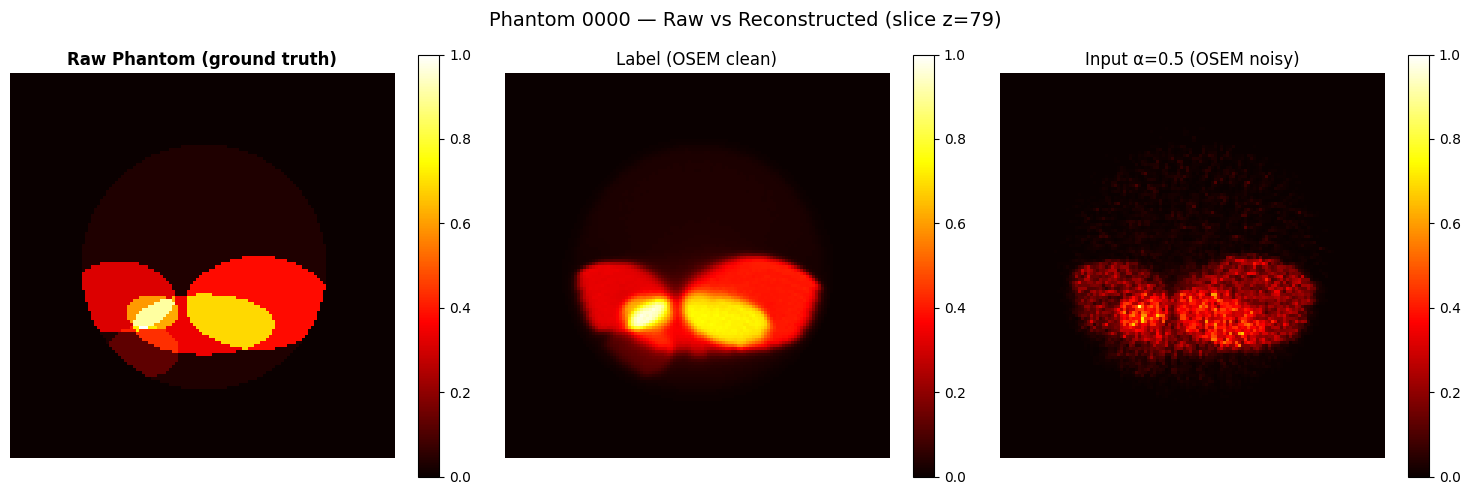

Saved to outputs/inspect_raw_vs_recon.png


In [21]:
# Generate the same phantom used during dataset creation (seed = 42 + PHANTOM_IDX)
phantom = generate_phantom(seed=42 + PHANTOM_IDX)
print(f"Phantom shape: {phantom.shape}, min: {phantom.min():.4f}, max: {phantom.max():.4f}")

# Find best slice from phantom
z_phantom = phantom.argmax() // (phantom.shape[1] * phantom.shape[2])
print(f"Phantom best slice: z={z_phantom}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Use same z for fair comparison
z = z_phantom

axes[0].imshow(phantom[z], cmap="hot")
axes[0].set_title("Raw Phantom (ground truth)", fontsize=12, fontweight="bold")
axes[0].axis("off")
fig.colorbar(plt.cm.ScalarMappable(cmap="hot"), ax=axes[0])

vmax = label.max()
axes[1].imshow(label[z], cmap="hot", vmin=0, vmax=vmax)
axes[1].set_title("Label (OSEM clean)", fontsize=12)
axes[1].axis("off")
fig.colorbar(plt.cm.ScalarMappable(cmap="hot"), ax=axes[1])

axes[2].imshow(inputs[0.5][z], cmap="hot", vmin=0, vmax=vmax)
axes[2].set_title("Input α=0.5 (OSEM noisy)", fontsize=12)
axes[2].axis("off")
fig.colorbar(plt.cm.ScalarMappable(cmap="hot"), ax=axes[2])

fig.suptitle(f"Phantom {PHANTOM_IDX:04d} — Raw vs Reconstructed (slice z={z})", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/inspect_raw_vs_recon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/inspect_raw_vs_recon.png")

## 6. Percentile Analysis

Max values can be distorted by hot spots (especially at low alpha).
Percentiles give a more robust picture of the value distribution.
99th percentile should scale roughly with alpha.

In [18]:
print(f"{'Alpha':<10} {'p50 (median)':>14} {'p95':>10} {'p99':>10} {'max':>10}")
print("-" * 58)

for alpha in ALPHA_VALUES:
    path = os.path.join(DATASET_DIR, ALPHA_DIRS[alpha], f"input_{PHANTOM_IDX:04d}.npy")
    arr = np.load(path).flatten()
    # Only look at non-zero voxels (inside the phantom)
    arr_nz = arr[arr > 0]
    p50  = np.percentile(arr_nz, 50)
    p95  = np.percentile(arr_nz, 95)
    p99  = np.percentile(arr_nz, 99)
    vmax = arr.max()
    print(f"  {alpha:<8} {p50:>14.4f} {p95:>10.4f} {p99:>10.4f} {vmax:>10.4f}")

print()
print("Label:")
arr = label.flatten()
arr_nz = arr[arr > 0]
print(f"  p50={np.percentile(arr_nz,50):.4f}, p95={np.percentile(arr_nz,95):.4f}, p99={np.percentile(arr_nz,99):.4f}, max={arr.max():.4f}")

Alpha        p50 (median)        p95        p99        max
----------------------------------------------------------
  1.0              0.0203     4.6395     8.5006    18.4393
  0.5              0.0090     2.3124     4.3978    11.3955
  0.25             0.0029     1.1383     2.3518     7.3056
  0.125            0.0006     0.5605     1.2995     5.2230
  0.05             0.0000     0.2185     0.6420    18.1124

Label:
  p50=0.0220, p95=4.6053, p99=7.9423, max=12.6213


## 7. Sum Ratio Verification

`sum(input) / sum(label)` should approximately equal alpha.
This verifies that the Poisson scaling was applied correctly in the sinogram domain.

In [19]:
label_sum = label.sum()
print(f"{'Alpha':<10} {'Expected':>12} {'Actual ratio':>14} {'Difference':>12}")
print("-" * 52)

for alpha in ALPHA_VALUES:
    path = os.path.join(DATASET_DIR, ALPHA_DIRS[alpha], f"input_{PHANTOM_IDX:04d}.npy")
    inp = np.load(path)
    ratio = inp.sum() / label_sum
    diff = abs(ratio - alpha)
    print(f"  {alpha:<8} {alpha:>12.4f} {ratio:>14.4f} {diff:>12.4f}")

Alpha          Expected   Actual ratio   Difference
----------------------------------------------------
  1.0            1.0000         0.9995       0.0005
  0.5            0.5000         0.4996       0.0004
  0.25           0.2500         0.2498       0.0002
  0.125          0.1250         0.1247       0.0003
  0.05           0.0500         0.0499       0.0001


## 8. Noise Level per Alpha

Relative noise = `std(input - label) / mean(label)`.
Should increase as alpha decreases (lower counts = more noise).

Alpha        Relative Noise
----------------------------
  1.0                0.7045
  0.5                1.5298
  0.25               2.1963
  0.125              2.5411
  0.05               2.7488


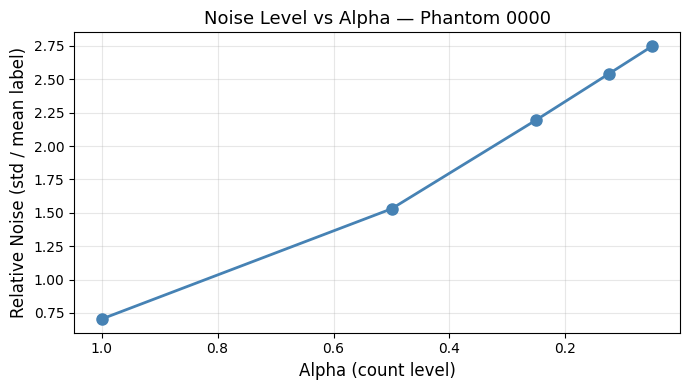

Saved to outputs/inspect_noise_vs_alpha.png


In [20]:
label_mean = label.mean()

print(f"{'Alpha':<10} {'Relative Noise':>16}")
print("-" * 28)

alphas_plot, noise_plot = [], []
for alpha in ALPHA_VALUES:
    path = os.path.join(DATASET_DIR, ALPHA_DIRS[alpha], f"input_{PHANTOM_IDX:04d}.npy")
    inp = np.load(path)
    rel_noise = np.std(inp - label) / label_mean
    alphas_plot.append(alpha)
    noise_plot.append(rel_noise)
    print(f"  {alpha:<8} {rel_noise:>16.4f}")

# Plot noise vs alpha
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas_plot, noise_plot, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_xlabel("Alpha (count level)", fontsize=12)
ax.set_ylabel("Relative Noise (std / mean label)", fontsize=12)
ax.set_title(f"Noise Level vs Alpha — Phantom {PHANTOM_IDX:04d}", fontsize=13)
ax.invert_xaxis()  # lower alpha = more noise, so invert for intuitive read
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/inspect_noise_vs_alpha.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/inspect_noise_vs_alpha.png")